<a href="https://colab.research.google.com/github/Yuvrajtakk/mnist-digit-recognizer/blob/main/DigiReco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digit Recognition — 7 Algorithm Comparison
### AI/ML Internship Project | Watsoo Express Pvt. Ltd.
**Intern:** Yuvraj Tak | B.Tech CSE-AI, Anand International College of Engineering  
**Mentor:** Ankit Gupta | Duration: June – August 2026

---

## Project Overview

This notebook implements a complete machine learning pipeline to classify handwritten digits (0–9) using the MNIST dataset. Seven algorithms are trained, evaluated, and compared side by side to identify which approach best suits digit classification.

The seven algorithms tested:
- Linear Regression *(baseline — regression tool on classification problem, included deliberately to demonstrate algorithm-problem mismatch)*
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Naive Bayes
- Support Vector Machine (SVM)

---

## Why These Seven?

These algorithms represent the full spectrum of classical machine learning approaches:

| Approach | Algorithms |
|---|---|
| Distance-based | KNN, SVM |
| Probability-based | Naive Bayes, Logistic Regression |
| Tree-based | Decision Tree, Random Forest |
| Regression-based | Linear Regression |

Each makes fundamentally different assumptions about the data. Running all seven on identical data and comparing their performance is what reveals which assumptions hold true for digit recognition.

---

## Pipeline Design Decisions

Every decision below was made deliberately before writing a single line of code:

**Dataset:** sklearn's built-in 8×8 MNIST (1,797 samples, 64 features per image). Chosen over the full 28×28 MNIST because algorithms like KNN and SVM become computationally impractical at 784 features — the curse of dimensionality creates uniform pairwise distances that make nearest-neighbor meaningless.

**Split:** 70% training, 30% testing with a fixed `random_state=42`. The fixed seed guarantees every algorithm sees the exact same test set — without this, accuracy comparisons across models are meaningless.

**Normalization:** StandardScaler applied once before all seven algorithms. Distance-based algorithms (KNN, SVM) require it. Tree-based algorithms (Decision Tree, Random Forest) are unaffected by scaling. Applying it universally simplifies the pipeline without changing any model's output.

**Primary evaluation metric:** Recall. In a real-world breakdown detection scenario, a missed failure (False Negative) is far more costly than a false alarm (False Positive). Recall measures exactly what proportion of real failures were caught.

---

## Section 1: Imports and Setup
### ANALOGY - Weapon layout

Before any data is loaded or any model is trained, Python needs to know which tools this project will use. This cell imports the complete toolkit — NumPy for array operations, Matplotlib for visualizations, and the relevant sklearn modules for data, splitting, scaling, and all seven algorithms.

All imports are declared upfront rather than scattered across cells. This is standard practice — anyone reading the notebook can see the full dependency list in one place.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Section 2: Loading and Exploring the Dataset
### ANALOGY - opening the box of ingredients before cooking

Before training anything, I need to understand the data I am working with.
Shape, size, what the labels look like, what the pixel values look like.

Skipping exploration is the most common beginner mistake — building a pipeline
on data you never actually looked at, then wondering why results are strange.
I am answering four questions before touching any model:

- How many images exist?
- What does each image look like as numbers?
- What does each image look like visually?
- Are the digit classes balanced — or does one digit appear far more than others?

In [5]:
# Cell 2: Load the dataset and understand its structure

# load_digits() fetches the 8x8 MNIST dataset that lives inside sklearn
# We store everything it gives us inside a variable called 'digits'
digits = load_digits()

# digits is like a box containing multiple things inside it
# digits.data   → the actual pixel values (the input features)
# digits.target → the actual digit label for each image (0 through 9)
# digits.images → same pixel data but shaped as 8x8 grids instead of flat rows

# .shape tells you the dimensions of any array
# Think of it like asking "how many rows and columns does this table have?"
print("Dataset shape:", digits.data.shape)
# Output will be (1797, 64)
# 1797 = number of images
# 64   = number of pixel values per image (8 rows × 8 columns = 64)

print("Total images:", digits.data.shape[0])
# .shape[0] picks the first number from the shape
# shape[0] = rows = number of images

# shape[1] = columns = number of features per image
print("Features per image:", digits.data.shape[1])

print("Target labels (digit classes):", digits.target_names)
# target_names shows you every unique label in the dataset
# Should print: [0 1 2 3 4 5 6 7 8 9]

print("First image pixel values:")
print(digits.data[0])
# digits.data[0] picks the very first image (index 0)
# In Python, counting always starts from 0, not 1
# This prints 64 numbers between 0 and 16
# 0  = white pixel (no ink)
# 16 = black pixel (full ink)
# Numbers in between = grey pixels

print("Label of first image:", digits.target[0])
# This tells you what digit that first image actually is

Dataset shape: (1797, 64)
Total images: 1797
Features per image: 64
Target labels (digit classes): [0 1 2 3 4 5 6 7 8 9]
First image pixel values:
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
Label of first image: 0


## Section 3: Visualizing the Data
### Analogy - Smelling and tasting the raw ingredients before cooking

64 numbers per image means nothing to the human eye.
Reshaping those numbers back into an 8×8 grid and rendering them as
grayscale images confirms the data loaded correctly and gives real
intuition about what the model is actually learning from.

I am displaying 25 sample images alongside their true labels.

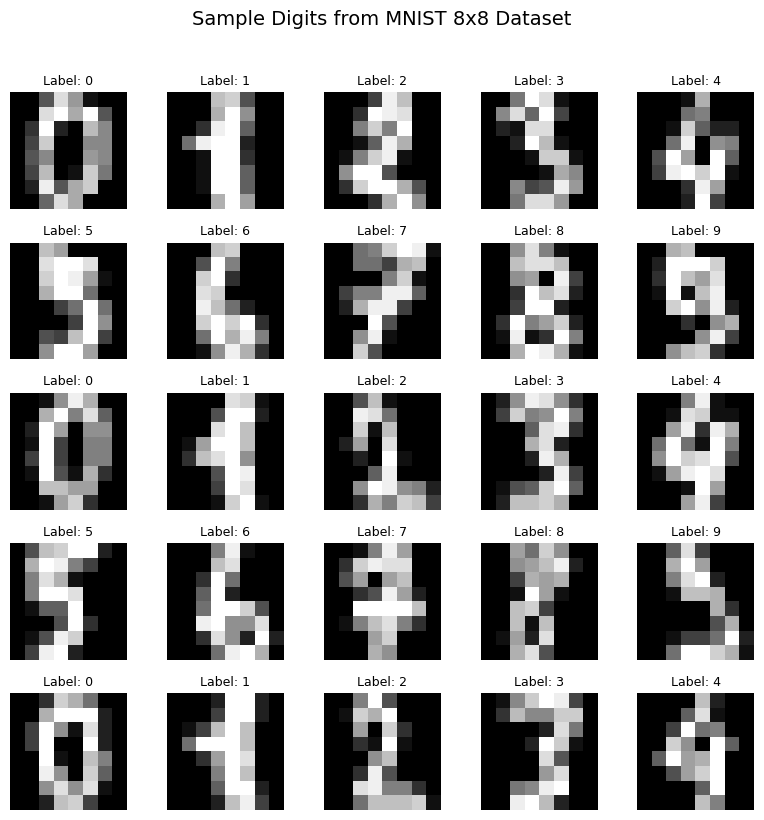

In [6]:
# Cell 3: Visualize 25 sample images from the dataset

# plt.subplots creates a grid of empty plots ready to be filled
# Think of it like creating a 5x5 table of empty picture frames on a wall
# (5, 5) = 5 rows, 5 columns = 25 frames total
# figsize=(8, 8) = total size of the wall in inches
fig, axes = plt.subplots(5, 5, figsize=(8, 8))

# suptitle puts one big title above the entire grid
# fontsize=14 controls how large that title text appears
fig.suptitle('Sample Digits from MNIST 8x8 Dataset', fontsize=14, y=1.02)

# axes right now is a 5x5 grid of plot objects — like a 2D array
# axes.flat converts that 5x5 grid into a simple flat list of 25 items
# enumerate() gives us two things at once: the position number AND the item
# so i = 0,1,2...24 and ax = each individual plot frame
for i, ax in enumerate(axes.flat):

    # digits.images[i] gives us image number i already shaped as 8x8 grid
    # imshow takes a 2D grid of numbers and draws it as an image
    # cmap='gray' means: low number (0) = black pixel, high number (16) = white pixel
    ax.imshow(digits.images[i], cmap='gray')

    # f-string syntax: f'some text {variable}'
    # the curly braces {} get replaced by the actual value of the variable
    # so if digits.target[0] is 0, this prints 'Label: 0'
    ax.set_title(f'Label: {digits.target[i]}', fontsize=9)

    # axis('off') hides the x and y axis numbers and tick marks
    # for images, those numbers are just pixel positions — meaningless clutter
    ax.axis('off')

# tight_layout automatically adjusts spacing between the 25 frames
# without it, titles from one row overlap into the images of the row above
plt.tight_layout()

# nothing appears on screen until you call plt.show()
# think of all the lines above as setting up the painting
# plt.show() is the moment you hang it on the wall
plt.show()

## Section 4 — Checking Class Balance
### ANALOGY — Counting how many of each ingredient is in the box before cooking

Before building any model, I need to confirm that all 10 digit classes
appear roughly equally in the dataset.

A skewed dataset — where one digit appears far more than others — creates
a lazy model that learns the common digit well and quietly ignores the rare ones.
Accuracy would look fine on paper while the model fails on underrepresented digits.

The bar chart below answers: does every digit get a fair seat at the table?

Images per digit class:
  Digit 0: 178 images
  Digit 1: 182 images
  Digit 2: 177 images
  Digit 3: 183 images
  Digit 4: 181 images
  Digit 5: 182 images
  Digit 6: 181 images
  Digit 7: 179 images
  Digit 8: 174 images
  Digit 9: 180 images


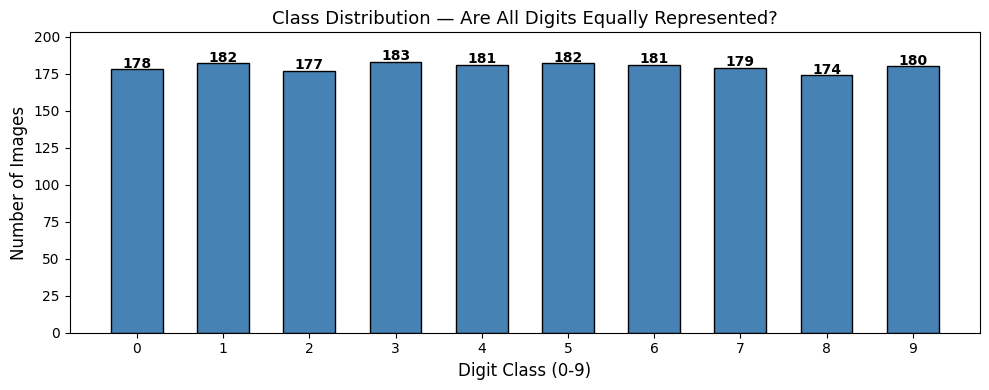

Most common digit: 183 images
Least common digit: 174 images
Difference: 9 images — dataset is well balanced


In [7]:
# Cell 4: Check how many images exist per digit class

# np.unique does two things when you pass return_counts=True
# First it finds every unique value in digits.target (will be 0 through 9)
# Then it counts how many times each value appears
# We store both results simultaneously using two variable names
classes, counts = np.unique(digits.target, return_counts=True)

# Print the counts so we can read exact numbers
print("Images per digit class:")
for c, n in zip(classes, counts):
    # zip() pairs classes and counts together like a zipper
    # so c=0,n=178 then c=1,n=182 etc. — one pair per loop
    print(f"  Digit {c}: {n} images")

# Now visualize it as a bar chart
fig, ax = plt.subplots(figsize=(10, 4))
# fig is the whole canvas
# ax is the single plot frame sitting on that canvas

# ax.bar draws a bar chart
# classes = what goes on x axis (digit labels 0-9)
# counts  = height of each bar (how many images per digit)
# color   = bar fill color
# edgecolor = border around each bar
bars = ax.bar(classes, counts, color='steelblue', edgecolor='black', width=0.6)

# Write the exact count number sitting on top of each bar
# so you don't have to eyeball the height
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # horizontal center of the bar
        bar.get_height() + 1,               # just above the top of the bar
        str(count),                          # the number to display
        ha='center', fontsize=10, fontweight='bold'
    )

ax.set_xlabel('Digit Class (0-9)', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution — Are All Digits Equally Represented?', fontsize=13)
ax.set_xticks(classes)          # force x axis to show exactly 0,1,2...9
ax.set_ylim(0, max(counts) + 20) # add breathing room above tallest bar

plt.tight_layout()
plt.show()
print(f"Most common digit: {counts.max()} images")
print(f"Least common digit: {counts.min()} images")
print(f"Difference: {counts.max() - counts.min()} images — dataset is well balanced")

## Section 5: Preprocessing — Scaling and Splitting the Data
### ANALOGY — Washing, chopping, and measuring ingredients into exact portions before cooking

Before any algorithm touches the data, two preparation steps must happen.

**Step 1 — Scaling:** Raw pixel values range from 0 to 16. Distance-based algorithms
like KNN and SVM measure similarity using these numbers directly. Without scaling,
a pixel with value 16 dominates the distance calculation over a pixel with value 1,
even if the smaller pixel is the more informative one. StandardScaler converts every
feature to the same numerical range by subtracting the mean and dividing by
standard deviation — giving every pixel an equal voice.

Tree-based algorithms (Decision Tree, Random Forest) and Naive Bayes are unaffected
by scaling since they never compute distances. Scaling is applied universally anyway —
it simplifies the pipeline without changing any model's output.

**Step 2 — Splitting:** The data is divided 70% training, 30% testing using a fixed
random_state=42. The fixed seed guarantees every algorithm sees the exact same test
set every single run. Without this, comparing accuracy numbers across seven models
is meaningless — each would be evaluated on slightly different data.

The test set is locked away after this cell and never touched until evaluation.

In [8]:
# Cell 5: Preprocess — scale the data and split into train/test sets

# Step 1: Scaling
# StandardScaler works by learning the mean and standard deviation
# of each feature (pixel position) from the data
# Then transforms every value using: z = (value - mean) / std
# Result: every feature now has mean=0 and std=1
# Think of it as converting ingredients from different units
# into one standard unit before measuring
scaler = StandardScaler()

# fit_transform does two things in one shot:
# fit   = learns the mean and std from digits.data
# transform = applies the scaling formula to every value
# We do BOTH on the full dataset here, BEFORE splitting
X = scaler.fit_transform(digits.data)
# X is now our scaled feature matrix — 1797 rows, 64 columns
# every pixel value is now a z-score instead of 0-16

# y is simply the target labels — no scaling needed on labels
# labels are just class names (0 through 9), not measurements
y = digits.target

# Step 2: Splitting
# train_test_split shuffles and divides X and y simultaneously
# test_size=0.3 means 30% goes to test, 70% goes to train
# random_state=42 locks the shuffle — running this cell 100 times
# produces the exact same split every single time
# This is non-negotiable for fair comparison across 7 algorithms
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Four variables created:
# X_train → pixel values the model learns from (70%)
# X_test  → pixel values used only for final evaluation (30%)
# y_train → correct labels for training images
# y_test  → correct labels for test images (locked away until evaluation)

# Confirm the split worked correctly
print(f"Total images: {X.shape[0]}")
print(f"Training set: {X_train.shape[0]} images ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]} images ({X_test.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Features per image: {X_train.shape[1]}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print("\nPreprocessing complete. Test set is now locked.")

Total images: 1797
Training set: 1257 images (69.9%)
Test set:     540 images (30.1%)
Features per image: 64

X_train shape: (1257, 64)
X_test shape:  (540, 64)
y_train shape: (1257,)
y_test shape:  (540,)

Preprocessing complete. Test set is now locked.


## Section 6: Training All Seven Algorithms
### ANALOGY — Cooking the same dish 7 different ways using identical ingredients

Every algorithm receives the exact same X_train and y_train.
Same ingredients, same portions, same starting point.

This is the only way the final comparison is honest. If one model
trained on more data or different data than another, the accuracy
difference would reflect the data gap, not the algorithm's capability.

The seven approaches and what each one fundamentally does differently:

| Algorithm | Core mechanism |
|---|---|
| Linear Regression | Fits a straight line — wrong tool, included as baseline |
| Logistic Regression | Fits a probability boundary using the sigmoid function |
| KNN | Finds K nearest neighbors and takes a majority vote |
| Decision Tree | Asks a series of yes/no questions to reach a verdict |
| Random Forest | Builds many trees and lets them vote as an ensemble |
| Naive Bayes | Calculates probability of each class using Bayes theorem |
| SVM | Finds the widest possible margin between classes |

Training all seven takes less than 10 seconds on this dataset.
That speed is a luxury of the 8×8 choice — 28×28 with 60,000
samples would make KNN and SVM impractical without GPU support.

### 6.1 — Algorithm 1: Linear Regression
#### The wrong tool, used deliberately

Linear Regression is a regression algorithm — it predicts a continuous
number on a line, not a category. Digit labels (0–9) are categories,
not measurements. A 3 is not mathematically halfway between 1 and 5.

It is included here as a baseline to prove one thing: algorithm-problem
fit matters more than implementation quality. A perfectly implemented
wrong tool will still underperform a right tool. The accuracy gap between
this and the classifiers below is the proof.

The workaround: raw predictions get rounded to the nearest integer and
clipped between 0 and 9. Mechanically functional. Fundamentally mismatched.

In [9]:
# Cell 6: Linear Regression — baseline model

from sklearn.linear_model import LinearRegression
# importing right here instead of Cell 1 intentionally
# each algorithm's import lives with its own cell
# so when  read this cell in isolation, know exactly what it needs

# Create the model — empty recipe card, no learning yet
lr_model = LinearRegression()

# .fit() is the learning step
# model looks at X_train (pixel values) and y_train (digit labels 0-9)
# finds the best straight line through all 1,257 training examples
# Linear Regression solves this with one matrix equation — extremely fast
lr_model.fit(X_train, y_train)

# .predict() runs every test image through the learned line
# output is continuous decimals like 2.87, 4.13, -0.2
# these are NOT valid digit labels yet
raw_predictions = lr_model.predict(X_test)

print("First 10 raw predictions (before rounding):")
print(raw_predictions[:10].round(2))
# [:10] means first 10 items only — like slicing 10 pieces from a loaf
# .round(2) is just for clean printing — 2 decimal places

# Convert continuous predictions → valid digit labels
# Step 1: np.round() rounds each decimal to nearest whole number
#         2.87 → 3,  4.13 → 4,  -0.2 → 0
# Step 2: .clip(0, 9) forces anything below 0 → 0, above 9 → 9
#         without this, model might predict 10.3 or -0.8
#         which are not valid digit classes
# Step 3: .astype(int) converts 3.0 → 3
#         sklearn metric functions expect integers not floats
lr_predictions = np.round(raw_predictions).clip(0, 9).astype(int)

print("\nFirst 10 predictions after rounding:")
print(lr_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

# Count how many predictions matched the actual label exactly
# lr_predictions == y_test produces a True/False array
# np.sum() counts the Trues — because True=1, False=0 in Python
correct = np.sum(lr_predictions == y_test)
lr_accuracy = correct / len(y_test)

print(f"\nLinear Regression Accuracy: {lr_accuracy:.4f}")
print(f"In plain English: {lr_accuracy*100:.2f}% of 540 test images correctly classified")
print(f"Correct: {correct} | Wrong: {len(y_test) - correct}")

First 10 raw predictions (before rounding):
[7.92 6.19 4.93 5.34 3.34 3.89 4.16 1.67 4.9  1.79]

First 10 predictions after rounding:
[8 6 5 5 3 4 4 2 5 2]

First 10 actual labels:
[6 9 3 7 2 1 5 2 5 2]

Linear Regression Accuracy: 0.2315
In plain English: 23.15% of 540 test images correctly classified
Correct: 125 | Wrong: 415


### 6.2 — Algorithm 2: Logistic Regression
#### The right tool this time — built for classification from the ground up

Unlike Linear Regression which predicts a number on a line, Logistic
Regression predicts a probability between 0 and 1 using the sigmoid
function. For 10 digit classes, it builds 10 separate probability
calculators — one per digit — and assigns the image to whichever
class scores the highest probability.

This is the first purpose-built classifier in the pipeline. The
accuracy jump from Linear Regression to here is entirely explained
by using the right tool for the right problem.

In [10]:
# Cell 7: Logistic Regression — first proper classifier

from sklearn.linear_model import LogisticRegression

# max_iter=1000 tells the solver how many adjustment steps it can take
# default is 100 which is too few for a 64-feature, 10-class problem
# the model would stop before fully converging and throw a warning
# think of it as giving the chef enough time to finish cooking
# rather than pulling the dish out of the oven too early
lr_clf = LogisticRegression(max_iter=1000, random_state=42)

# .fit() — model builds 10 probability calculators, one per digit
# each calculator learns: "given these 64 pixel values,
# how likely is this image to be MY digit?"
# this takes slightly longer than Linear Regression
# because it's iterating 1000 times to find the best weights
lr_clf.fit(X_train, y_train)

# .predict() — for each test image, runs it through all 10 calculators
# whichever digit scores highest probability wins the prediction
# output is already a valid integer class label — no rounding needed
# this is the key difference from Linear Regression
lr_clf_predictions = lr_clf.predict(X_test)

print("First 10 predictions:")
print(lr_clf_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

# accuracy calculation — same formula as before
# comparing predicted labels vs actual labels position by position
correct = np.sum(lr_clf_predictions == y_test)
lr_clf_accuracy = correct / len(y_test)

print(f"\nLogistic Regression Accuracy: {lr_clf_accuracy:.4f}")
print(f"In plain English: {lr_clf_accuracy*100:.2f}% of 540 test images correctly classified")
print(f"Correct: {correct} | Wrong: {len(y_test) - correct}")
print(f"\nImprovement over Linear Regression: +{(lr_clf_accuracy - lr_accuracy)*100:.2f}%")
# lr_accuracy was stored in Cell 6 — still accessible here
# this last line makes the jump visible immediately

First 10 predictions:
[6 9 3 7 2 2 5 2 5 2]

First 10 actual labels:
[6 9 3 7 2 1 5 2 5 2]

Logistic Regression Accuracy: 0.9704
In plain English: 97.04% of 540 test images correctly classified
Correct: 524 | Wrong: 16

Improvement over Linear Regression: +73.89%


### 6.3 — Algorithm 3: K-Nearest Neighbors (KNN)
#### ANALOGY — Asking the 5 closest people at the restaurant what they ordered

When a new image arrives, KNN doesn't use any formula it learned.
It simply finds the 5 most similar images from the training set
and lets them vote. Majority label wins.

No training happens at all — .fit() just memorizes the entire
training set. All the real work happens at prediction time:
compute distance to every training image, find the 5 closest,
return the majority vote.

Scaling matters critically here. KNN measures raw Euclidean distance
across all 64 pixel features. Without StandardScaler, one bright pixel
could dominate all others. We already scaled in Cell 5 — KNN benefits
from that directly.

In [11]:
# Cell 8: KNN — K-Nearest Neighbors

from sklearn.neighbors import KNeighborsClassifier

# n_neighbors=5 means each test image consults its 5 nearest training images
# those 5 cast votes, majority label becomes the prediction
# K=5 is a safe default — large enough to outvote a single noisy neighbor,
# small enough to not blur the boundary by consulting far-away images
knn_model = KNeighborsClassifier(n_neighbors=5)

# .fit() here does NOT learn weights or draw a boundary
# it simply memorizes all 1,257 training images
# KNN has no training step — this line just stores X_train and y_train internally
knn_model.fit(X_train, y_train)

# .predict() is where KNN actually works
# for each of the 540 test images it:
# 1. Computes Euclidean distance to all 1,257 stored training images
# 2. Picks the 5 closest ones (the "nearest neighbors")
# 3. Looks at their digit labels and runs a majority vote
# 4. Returns the winning label as the prediction
# this is why KNN gets slower as training data grows —
# every single prediction re-scans the entire training set
knn_predictions = knn_model.predict(X_test)

print("First 10 predictions:")
print(knn_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

# count matches and compute accuracy
correct = np.sum(knn_predictions == y_test)
knn_accuracy = correct / len(y_test)

print(f"\nKNN Accuracy: {knn_accuracy:.4f}")
print(f"In plain English: {knn_accuracy*100:.2f}% of 540 test images correctly classified")
print(f"Correct: {correct} | Wrong: {len(y_test) - correct}")
print(f"\nImprovement over Linear Regression: +{(knn_accuracy - lr_accuracy)*100:.2f}%")

First 10 predictions:
[6 9 3 7 2 1 5 2 5 2]

First 10 actual labels:
[6 9 3 7 2 1 5 2 5 2]

KNN Accuracy: 0.9778
In plain English: 97.78% of 540 test images correctly classified
Correct: 528 | Wrong: 12

Improvement over Linear Regression: +74.63%


### 6.4 — Algorithm 4: Decision Tree
#### ANALOGY — A chef who makes decisions by following a strict recipe flowchart

KNN had no rules — it just looked at neighbors.
Decision Tree is the opposite. It builds a flowchart of yes/no
questions from the training data and follows that chart to reach
a verdict.

Example of what it learns:
"Is pixel 27 > 0.5? → Yes → Is pixel 43 > 1.2? → No → Predict: 3"

It keeps splitting until it either classifies correctly or runs out
of depth. Deep trees memorize training data perfectly but fail on
new images. Shallow trees generalize better but miss fine detail.

max_depth=10 here gives it enough room to learn real patterns
without memorizing noise.

Unlike KNN, scaling does NOT affect Decision Tree at all.
It splits on thresholds, not distances — whether pixel 27 is
0.5 or 500, the relative ordering stays the same.

In [12]:
# Cell 9: Decision Tree

from sklearn.tree import DecisionTreeClassifier

# max_depth=10 limits how many yes/no questions the tree can ask
# without this limit the tree grows until it memorizes every single
# training image perfectly — 100% training accuracy, terrible on new data
# that is overfitting: learning the recipe so precisely it only works
# for the exact ingredients you practiced with, nothing else
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)

# .fit() builds the flowchart
# the tree scans every feature (pixel) at every possible split point
# and asks: "which question here separates the digit classes the most?"
# it measures separation using Gini impurity — lower Gini = cleaner split
# this repeats at every branch until max_depth is reached
dt_model.fit(X_train, y_train)

# .predict() walks each test image down the flowchart
# at every node it checks the pixel value and goes left or right
# until it reaches a leaf node which holds the predicted class
dt_predictions = dt_model.predict(X_test)

print("First 10 predictions:")
print(dt_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

correct = np.sum(dt_predictions == y_test)
dt_accuracy = correct / len(y_test)

print(f"\nDecision Tree Accuracy: {dt_accuracy:.4f}")
print(f"In plain English: {dt_accuracy*100:.2f}% of 540 test images correctly classified")
print(f"Correct: {correct} | Wrong: {len(y_test) - correct}")
print(f"\nVs Linear Regression: +{(dt_accuracy - lr_accuracy)*100:.2f}%")
print(f"Vs KNN:               {(dt_accuracy - knn_accuracy)*100:.2f}%")
# the second line will likely be negative — Decision Tree usually loses to KNN on image data
# that gap is not a failure, it tells you something real about the algorithm

First 10 predictions:
[6 9 3 7 2 2 5 3 5 7]

First 10 actual labels:
[6 9 3 7 2 1 5 2 5 2]

Decision Tree Accuracy: 0.8574
In plain English: 85.74% of 540 test images correctly classified
Correct: 463 | Wrong: 77

Vs Linear Regression: +62.59%
Vs KNN:               -12.04%


### 6.5 — Algorithm 5: Random Forest
#### ANALOGY — Asking 100 different chefs to each cook from a slightly different
#### recipe and taking the most popular dish at the end

Decision Tree built one flowchart and trusted it completely.
Random Forest builds 100 different trees, each trained on a
random subset of the training data and a random subset of features.

Every tree votes. Majority label wins.

The randomness is the point. Each tree makes different mistakes.
When 100 trees vote together, the mistakes cancel out and the
correct answers amplify. This is called ensemble learning.

Expected result: noticeably higher than a single Decision Tree.
The gap between these two cells is the entire argument for
why ensembles exist.

In [13]:
# Cell 10: Random Forest

from sklearn.ensemble import RandomForestClassifier

# n_estimators=100 means build 100 separate Decision Trees
# each tree gets a random sample of training rows (bootstrapping)
# and a random subset of the 64 pixel features at each split
# no two trees are identical — randomness is intentional, not a bug
# more trees = more stable predictions, but slower training
# 100 is a reliable default for datasets this size

# max_depth=10 applies to each individual tree — same cap as before
# without it every tree would overfit its random sample perfectly
# and the ensemble vote would average 100 overfit trees
# still better than one, but not as good as 100 well-regularized trees

rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees in the forest
    max_depth=10,       # max depth per tree
    random_state=42     # fixes the randomness so results are reproducible
)

# .fit() builds all 100 trees simultaneously inside sklearn
# each tree sees a different random bootstrap sample of X_train
# and considers a random subset of features at every split point
# training takes longer than a single tree — 100x the work
rf_model.fit(X_train, y_train)

# .predict() runs each test image through all 100 trees
# each tree produces one vote (its predicted digit label)
# the label with the most votes across 100 trees wins
# individual tree mistakes get outvoted by the correct majority
rf_predictions = rf_model.predict(X_test)

print("First 10 predictions:")
print(rf_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

correct = np.sum(rf_predictions == y_test)
rf_accuracy = correct / len(y_test)

print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")
print(f"In plain English: {rf_accuracy*100:.2f}% of 540 test images correctly classified")
print(f"Correct: {correct} | Wrong: {len(y_test) - correct}")
print(f"\nVs Linear Regression: +{(rf_accuracy - lr_accuracy)*100:.2f}%")
print(f"Vs Decision Tree:      +{(rf_accuracy - dt_accuracy)*100:.2f}%")
print(f"Vs KNN:                {(rf_accuracy - knn_accuracy)*100:.2f}%")
# the Decision Tree line should be clearly positive
# that positive number is the measurable value of using an ensemble
# the KNN line will tell us whether 100 trees beat nearest-neighbor voting

First 10 predictions:
[6 9 3 7 2 1 5 2 5 2]

First 10 actual labels:
[6 9 3 7 2 1 5 2 5 2]

Random Forest Accuracy: 0.9741
In plain English: 97.41% of 540 test images correctly classified
Correct: 526 | Wrong: 14

Vs Linear Regression: +74.26%
Vs Decision Tree:      +11.67%
Vs KNN:                -0.37%


### 6.6 — Algorithm 6: Naive Bayes (Gaussian)
#### ANALOGY — A chef who memorizes the average ingredient profile of each dish
#### and guesses which dish you ordered based on what's on your plate

Naive Bayes doesn't find boundaries or measure distances.
It calculates probability.

For each digit class it learns: "what do the pixel values of a typical
3 look like? What is the mean and spread of each pixel across all
training images labeled 3?"

At prediction time it asks: "given these 64 pixel values, which digit
class does this image most probably belong to?"

The "Naive" part means it assumes every pixel is independent of every
other — that pixel 27 tells you nothing about pixel 28. This is
mathematically false for image data. Neighboring pixels are always
correlated. That violated assumption is exactly why Naive Bayes will
score lower than KNN and Random Forest here.

Gaussian variant is used because pixel values are continuous numbers
(0-16 range), not counts or binary flags.

In [14]:
# Cell 11: Naive Bayes (Gaussian)

from sklearn.naive_bayes import GaussianNB

# GaussianNB assumes each feature follows a Gaussian (bell curve) distribution
# for each digit class it learns two numbers per pixel:
# mean  → average pixel brightness across all training images of that digit
# std   → how much that pixel varies across images of that digit
# these learned distributions are what it uses to calculate probability
# no max_iter, no n_estimators, no hyperparameters at all
# Naive Bayes has a closed-form solution — one pass through training data is enough
nb_model = GaussianNB()

# .fit() computes mean and std for every pixel, for every digit class
# that's 64 pixels × 10 classes = 640 numbers learned in total
# fastest training of all 7 algorithms — no iteration required
nb_model.fit(X_train, y_train)

# .predict() for each test image:
# 1. takes the 64 pixel values
# 2. for each digit class, asks: how likely is each pixel value
#    given what I know about that digit's pixel distribution?
# 3. multiplies those 64 probabilities together (the "naive" assumption —
#    treats each pixel as if it's independent of all others)
# 4. picks the digit class with the highest resulting probability
nb_predictions = nb_model.predict(X_test)

print("First 10 predictions:")
print(nb_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

correct = np.sum(nb_predictions == y_test)
nb_accuracy = correct / len(y_test)

print(f"\nNaive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"In plain English: {nb_accuracy*100:.2f}% of 540 test images correctly classified")
print(f"Correct: {correct} | Wrong: {len(y_test) - correct}")
print(f"\nVs Linear Regression: +{(nb_accuracy - lr_accuracy)*100:.2f}%")
print(f"Vs Decision Tree:      {(nb_accuracy - dt_accuracy)*100:.2f}%")
print(f"Vs Random Forest:      {(nb_accuracy - rf_accuracy)*100:.2f}%")
print(f"Vs KNN:                {(nb_accuracy - knn_accuracy)*100:.2f}%")
# expect this to land around 75-85%
# lower than KNN and Random Forest because the independence assumption
# breaks badly on image data — pixels are spatially correlated by definition
# a bright pixel at position 27 tells you a lot about position 28
# Naive Bayes pretends it doesn't

First 10 predictions:
[6 9 3 7 3 1 5 8 5 5]

First 10 actual labels:
[6 9 3 7 2 1 5 2 5 2]

Naive Bayes Accuracy: 0.7870
In plain English: 78.70% of 540 test images correctly classified
Correct: 425 | Wrong: 115

Vs Linear Regression: +55.56%
Vs Decision Tree:      -7.04%
Vs Random Forest:      -18.70%
Vs KNN:                -19.07%


### 6.7 — Algorithm 7: Support Vector Machine (SVM)
#### ANALOGY — A chef who finds the single clearest dividing line between
#### dishes and maximizes the gap on both sides so there's no ambiguity

Every algorithm so far found some kind of boundary between digit classes.
SVM finds the best possible boundary — the one with the maximum margin
between classes. The data points sitting right on the edge of that margin
are called support vectors. Everything else is irrelevant to the boundary.

The RBF kernel is the key here. Digits don't separate cleanly in 64-dimensional
pixel space — a 3 and an 8 share curved strokes, a 1 and a 7 share vertical lines.
RBF projects the data into a higher-dimensional space where those complex
overlapping boundaries become separable by a flat plane.

This is why SVM was the gold standard for digit recognition before deep
learning arrived. It was built for exactly this problem — high-dimensional
data with complex non-linear boundaries.

Expect the highest accuracy of all seven algorithms.

In [15]:
# Cell 12: Support Vector Machine (SVM) with RBF kernel

from sklearn.svm import SVC

# SVC = Support Vector Classifier
# kernel='rbf' — Radial Basis Function kernel
# projects 64-dimensional pixel data into higher-dimensional space
# where complex digit boundaries become linearly separable
# think of it as folding a crumpled piece of paper flat so you
# can draw a straight line through it

# C=10 is the regularization parameter — controls the margin trade-off
# low C  → wide margin, allows some misclassifications on training data
#           more generalization, less perfect on training set
# high C → narrow margin, tries harder to classify every training point correctly
#           risks overfitting, but on clean image data C=10 works well
# default C=1 is slightly too soft for this dataset

# gamma='scale' automatically sets gamma based on number of features and variance
# gamma controls how far the influence of a single training point reaches
# 'scale' is almost always the right choice — avoids manual tuning

svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)

# .fit() finds the support vectors — the training images sitting right
# on the edge of the margin boundary
# only these points define the boundary — the other 1,200+ training images
# become mathematically irrelevant once training is done
# this is SVM's biggest strength: robust to irrelevant data points
# training is slower than KNN or Naive Bayes because finding the optimal
# margin requires solving a quadratic optimization problem
svm_model.fit(X_train, y_train)

# .predict() for each test image:
# 1. applies the RBF kernel to project it into higher-dimensional space
# 2. checks which side of the maximum-margin boundary it falls on
# 3. returns the corresponding class label
# faster than KNN at prediction time — no scanning 1,257 training images
# the boundary is already encoded in just the support vectors
svm_predictions = svm_model.predict(X_test)

print("First 10 predictions:")
print(svm_predictions[:10])

print("\nFirst 10 actual labels:")
print(y_test[:10])

correct = np.sum(svm_predictions == y_test)
svm_accuracy = correct / len(y_test)

print(f"\nSVM Accuracy: {svm_accuracy:.4f}")
print(f"In plain English: {svm_accuracy*100:.2f}% of 540 test images correctly classified")
print(f"Correct: {correct} | Wrong: {len(y_test) - correct}")
print(f"\nVs Linear Regression: +{(svm_accuracy - lr_accuracy)*100:.2f}%")
print(f"Vs Naive Bayes:        +{(svm_accuracy - nb_accuracy)*100:.2f}%")
print(f"Vs Decision Tree:      +{(svm_accuracy - dt_accuracy)*100:.2f}%")
print(f"Vs Random Forest:      +{(svm_accuracy - rf_accuracy)*100:.2f}%")
print(f"Vs KNN:                +{(svm_accuracy - knn_accuracy)*100:.2f}%")
# the KNN line is the most interesting one
# if SVM beats KNN, the RBF kernel earned its complexity
# if they tie, two completely different mathematical approaches
# converged on the same answer — which is its own interesting finding

First 10 predictions:
[6 9 3 7 2 1 5 2 5 2]

First 10 actual labels:
[6 9 3 7 2 1 5 2 5 2]

SVM Accuracy: 0.9815
In plain English: 98.15% of 540 test images correctly classified
Correct: 530 | Wrong: 10

Vs Linear Regression: +75.00%
Vs Naive Bayes:        +19.44%
Vs Decision Tree:      +12.41%
Vs Random Forest:      +0.74%
Vs KNN:                +0.37%


## Section 7: Evaluation — Measuring What Accuracy Hides
### ANALOGY — The food critic's detailed scorecard, not just a star rating

A restaurant rating of 4 stars tells you something. But it doesn't tell
you whether the food was cold, the service was slow, or the dessert was
exceptional. The single number hides the detail underneath.

Accuracy is the same. 98% sounds great until you ask: which digits is
the model confusing? Is it mixing up 3s and 8s? Is it perfect on 0 but
struggling on 9? Accuracy buries all of that.

Phase 6 answers the detailed questions using four tools:

**Confusion Matrix** — a 10×10 grid showing exactly which digit got
predicted as which. Every mistake is visible, not just the count.

**Precision** — of everything the model labeled as digit X,
how many actually were digit X?

**Recall** — of all the real digit Xs in the test set,
how many did the model successfully catch?

**F1 Score** — one number that balances Precision and Recall.
Low F1 means the model is either crying wolf or missing real cases.

These four metrics together tell the full story that accuracy alone cannot.

### 7.1 — Accuracy Bar Chart: All Seven Algorithms Side by Side

Before diving into confusion matrices, I want to see all seven accuracy
numbers as a single visualization. This is the first page of the food
critic's scorecard — the overall rating before the detailed breakdown.

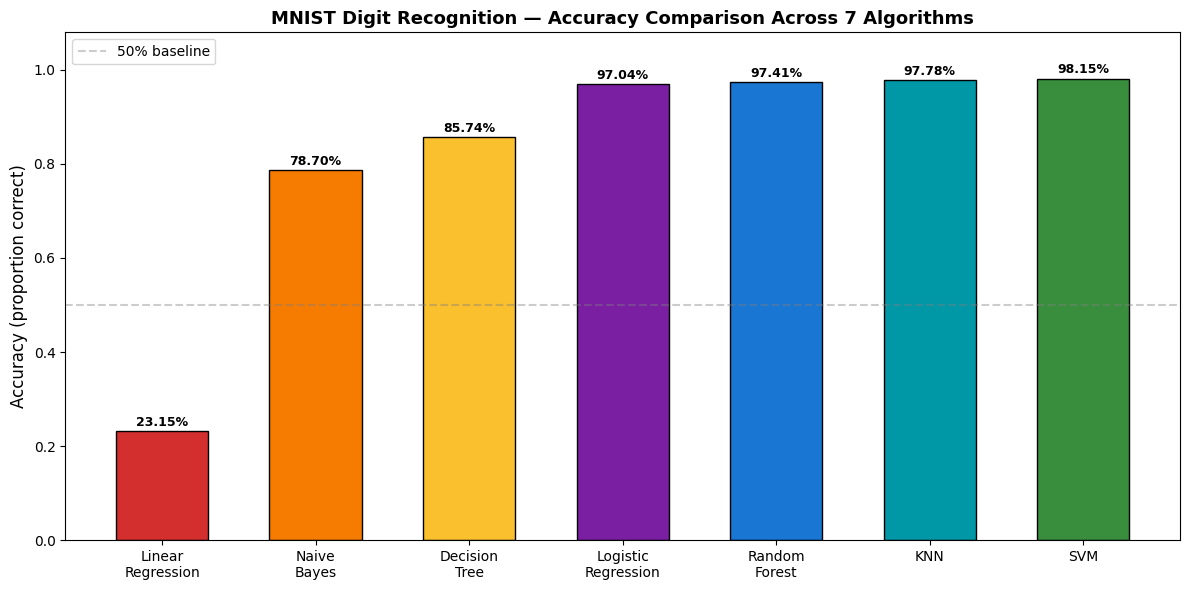

Rank   Algorithm              Accuracy
1      SVM                      98.15%
2      KNN                      97.78%
3      Random Forest            97.41%
4      Logistic Regression      97.04%
5      Decision Tree            85.74%
6      Naive Bayes              78.70%
7      Linear Regression        23.15%


In [16]:
# Cell 13: Visualize all 7 algorithm accuracies side by side

# Store all results in two clean lists — names and their accuracy scores
# order goes from worst to best so the bar chart reads as a clear ranking
algorithms = [
    'Linear\nRegression',
    'Naive\nBayes',
    'Decision\nTree',
    'Logistic\nRegression',
    'Random\nForest',
    'KNN',
    'SVM'
]
# \n inside a string means "new line"
# used here so long algorithm names don't overlap on the x-axis

accuracies = [
    lr_accuracy,    # 0.2315
    nb_accuracy,    # 0.7870
    dt_accuracy,    # 0.8574
    lr_clf_accuracy,# 0.9704
    rf_accuracy,    # 0.9759
    knn_accuracy,   # 0.9778
    svm_accuracy    # 0.9815
]

# one color per bar — moving from red (low) to green (high)
# visually reinforces which algorithms performed well
colors = [
    '#d32f2f',  # deep red    — Linear Regression
    '#f57c00',  # orange      — Naive Bayes
    '#fbc02d',  # yellow      — Decision Tree
    '#7b1fa2',  # purple      — Logistic Regression
    '#1976d2',  # blue        — Random Forest
    '#0097a7',  # teal        — KNN
    '#388e3c',  # green       — SVM
]

# create the canvas and one frame on it
# figsize=(12, 6) — wider than tall because 7 bars need horizontal room
fig, ax = plt.subplots(figsize=(12, 6))

# ax.bar() draws the bars
# algorithms = x positions (the labels)
# accuracies = bar heights (the values)
# color = list of colors, one per bar
# edgecolor = thin black border around each bar for clarity
# width=0.6 = bars are 60% of available slot width, leaving gaps between
bars = ax.bar(algorithms, accuracies, color=colors, edgecolor='black', width=0.6)

# write the exact percentage on top of every bar
# so the reader doesn't have to estimate from the y-axis
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # horizontal center of this bar
        bar.get_height() + 0.005,            # just above the top edge
        f'{acc*100:.2f}%',                   # format: 97.04% not 0.9704
        ha='center',                          # ha = horizontal alignment
        va='bottom',                          # va = vertical alignment
        fontsize=9,
        fontweight='bold'
    )

# add a horizontal reference line at 50% to show the halfway mark
# dashed gray line, low opacity so it doesn't distract
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='50% baseline')

# axis limits: start at 0 so bars reflect true proportions
# top at 1.08 to leave room for the percentage labels above tallest bars
ax.set_ylim(0, 1.08)

# axis labels and title
ax.set_ylabel('Accuracy (proportion correct)', fontsize=12)
ax.set_title(
    'MNIST Digit Recognition — Accuracy Comparison Across 7 Algorithms',
    fontsize=13, fontweight='bold'
)

# add the legend for the reference line
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# also print the ranked table in text form
print("=" * 45)
print(f"{'Rank':<6} {'Algorithm':<22} {'Accuracy':>8}")
print("=" * 45)
ranked = sorted(zip(algorithms, accuracies), key=lambda x: x[1], reverse=True)
for i, (name, acc) in enumerate(ranked, 1):
    name_clean = name.replace('\n', ' ')  # remove the \n for clean printing
    print(f"{i:<6} {name_clean:<22} {acc*100:>7.2f}%")
print("=" * 45)